# Video Game Sales Prediction Using Machine Learning
## Project Overview

This project focuses on predicting video game sales using machine learning regression techniques.

The analysis includes data cleaning, exploratory data analysis (EDA), feature engineering, categorical encoding, model training, hyperparameter tuning, and model interpretation using SHAP.

Several regression models were compared, including:

- Linear Regression
- Decision Tree
- Random Forest
- XGBoost
- Tuned XGBoost

The final model was selected based on MAE, RMSE, and R² evaluation metrics.

## Problem Statement

The objective of this project is to predict the total sales of video games based on available information such as platform, genre, publisher, developer, and release year.

Because the sales distribution is highly right-skewed, a logarithmic transformation was applied to the target variable before model training.

The target variable used in the machine learning models is:

log_total_sales

## Dataset

The dataset contains information about video games, including:

- Console / Platform
- Genre
- Publisher
- Developer
- Release Date
- Total Sales
- Regional Sales

The analysis focuses on observations with available total sales values.

## Methodology

The project follows the following workflow:

1. Data loading and inspection
2. Data cleaning
3. Handling missing values
4. Exploratory Data Analysis
5. Target transformation using logarithm
6. Feature engineering
7. Categorical feature encoding
8. Train-test split
9. Regression model training
10. Model evaluation
11. Hyperparameter tuning
12. Feature importance analysis
13. SHAP-based model interpretation
14. Final model selection

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
import shap

# 1. Data Loading

In [2]:
df = pd.read_csv("data/vgchartz-2024.csv")

# 2. Initial Data Inspection

In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales
count,6678.000000,18922.000000,12637.000000,6726.000000,12824.000000,15128.000000
mean,7.220440,0.349113,0.264740,0.102281,0.149472,0.043041
std,1.457066,0.807462,0.494787,0.168811,0.392653,0.126643
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.400000,0.030000,0.050000,0.020000,0.010000,0.000000
50%,7.500000,0.120000,0.120000,0.040000,0.040000,0.010000
75%,8.300000,0.340000,0.280000,0.120000,0.140000,0.030000
max,10.000000,20.320000,9.760000,2.130000,9.850000,3.120000


In [4]:
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


# 3. Data Cleaning

The dataset was cleaned and prepared for machine learning through several steps.

First, rows with missing values in the target variable total_sales were removed because these observations cannot be used for supervised regression.

Several columns were excluded because they were not required for the prediction task, including image URLs, game titles, regional sales variables, and update information.

The original release_date variable was transformed into release_year to provide a more useful numerical feature.

After cleaning, the remaining features were prepared for modeling using appropriate encoding techniques.

In [5]:
df.duplicated().sum()

0

In [6]:
#check missing value
df.isnull().sum()

img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64

### 3.1 Feature Selection

Several columns were excluded because they were not considered useful for the current prediction task.

The selected variables are:

- console
- genre
- publisher
- developer
- total_sales
- release_date

In [7]:
columns_to_drop = [
    "img",
    "title",
    "critic_score",
    "na_sales",
    "jp_sales",
    "pal_sales",
    "other_sales",
    "last_update"
]

df = df.drop(columns=columns_to_drop)

In [8]:
df.isnull().sum()

console             0
genre               0
publisher           0
developer          17
total_sales     45094
release_date     7051
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   console       64016 non-null  object 
 1   genre         64016 non-null  object 
 2   publisher     64016 non-null  object 
 3   developer     63999 non-null  object 
 4   total_sales   18922 non-null  float64
 5   release_date  56965 non-null  object 
dtypes: float64(1), object(5)
memory usage: 2.9+ MB


### 3.2 Handling Missing Target Values

Rows with missing total_sales values were removed because total sales is required as the target variable for supervised learning.

In [10]:
df = df.dropna(subset=["total_sales"])

### 3.3 Missing Value Analysis

After removing observations with missing target values, the remaining variables were checked for missing values.

In [11]:
df.isnull().sum()

console          0
genre            0
publisher        0
developer        4
total_sales      0
release_date    90
dtype: int64

In [12]:
df.shape

(18922, 6)

In [13]:
df = df.dropna(subset=["developer"])

### 3.4 Feature Engineering: Release Year

The original release_date variable was converted into release_year.

The year is more suitable for the machine learning models than the original date format.

In [14]:
df["release_date"] = pd.to_datetime(
    df["release_date"],
    errors="coerce"
)

df["release_year"] = df["release_date"].dt.year

df = df.dropna(subset=["release_year"])

df = df.drop(columns=["release_date"])

### 3.5 Log Transformation of Total Sales

The distribution of total_sales was highly right-skewed with several extreme values.

To reduce the effect of extreme observations and make the target distribution more suitable for regression models, a logarithmic transformation was applied.

The transformed target is stored as log_total_sales.

In [15]:
df["log_total_sales"] = np.log1p(df["total_sales"])

### 3.6 Distribution of the Transformed Target

The distribution of log_total_sales was visualized to evaluate the effect of the logarithmic transformation.

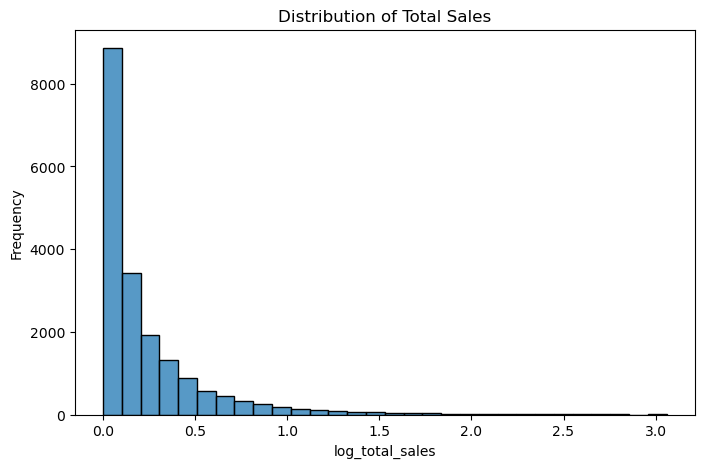

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df["log_total_sales"], bins=30)
 
plt.title("Distribution of Total Sales")
plt.xlabel("log_total_sales")
plt.ylabel("Frequency")

plt.show()

# 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the distribution of the target variable, identify potential outliers, and examine relationships between numerical and categorical features.

### 4.1 Distribution of Total Sales

The distribution of total sales was examined to identify skewness and extreme values.

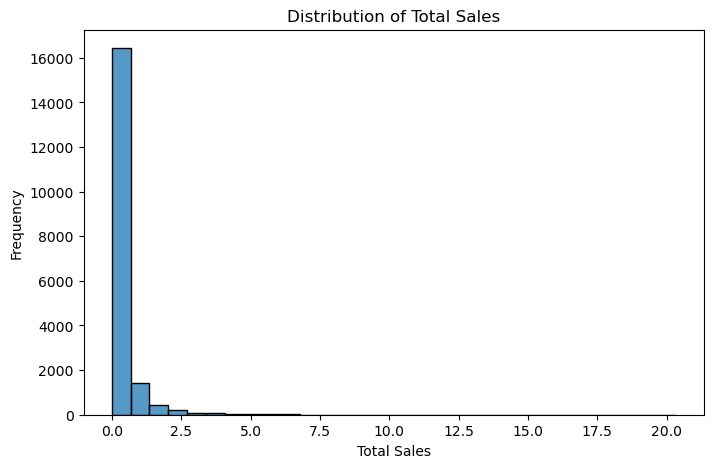

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df["total_sales"], bins=30)

plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")

plt.show()

### 4.2 Categorical Feature Analysis: Genre

The distribution of games across different genres was examined to identify the most common and least represented categories.

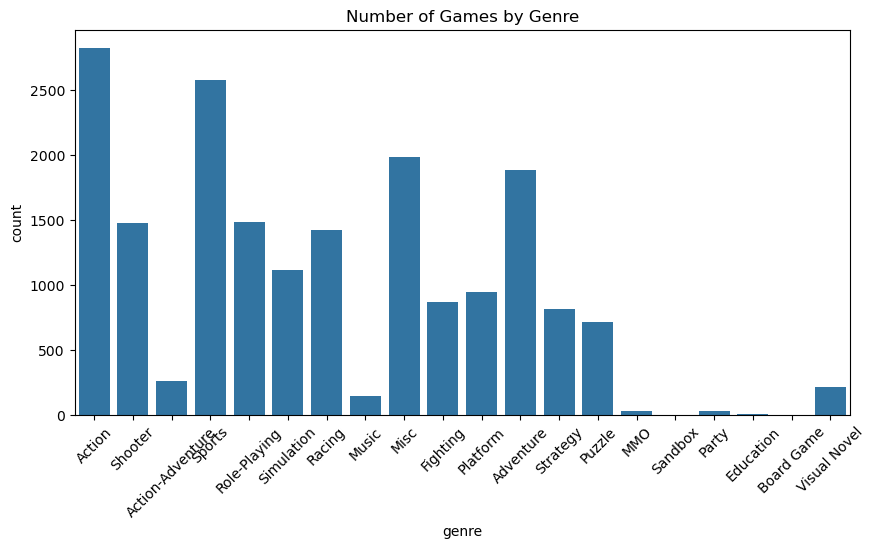

In [18]:
#Explore Categorical Features

plt.figure(figsize=(10,5))
sns.countplot(data=df , x="genre")
plt.title("Number of Games by Genre")
plt.xticks(rotation=45)
plt.show()

In [19]:
df.genre.value_counts().sort_values()

genre
Sandbox                1
Board Game             3
Education              4
Party                 29
MMO                   30
Music                147
Visual Novel         218
Action-Adventure     264
Puzzle               719
Strategy             817
Fighting             867
Platform             949
Simulation          1116
Racing              1422
Shooter             1479
Role-Playing        1483
Adventure           1888
Misc                1987
Sports              2581
Action              2825
Name: count, dtype: int64

### 4.3 Rare Category Analysis

Genres with very few observations were removed because the limited number of samples could provide insufficient information for reliable model training.

In [20]:
rare_genres = ["Board Game" , "Education", "Sandbox"]
df = df[~df["genre"].isin(rare_genres)]

In [21]:
df.shape

(18821, 7)

# 5. Feature Engineering and Encoding

Categorical variables were transformed into numerical representations suitable for machine learning models.

Frequency encoding was applied to publisher and developer, while One-Hot Encoding was used for console and genre.

In [22]:
df_model = df.copy()

### 5.1 Frequency Encoding

Publisher and developer were frequency-encoded to avoid creating a very large number of dummy variables.

The frequency represents the proportion of observations associated with each publisher or developer.

In [23]:
publisher_freq = df_model["publisher"].value_counts(normalize=True)
developer_freq = df_model["developer"].value_counts(normalize=True)

df_model["publisher_freq"] = df_model["publisher"].map(publisher_freq)
df_model["developer_freq"] = df_model["developer"].map(developer_freq)
df_model = df_model.drop(
    columns=["publisher", "developer"]
)

### 5.2 One-Hot Encoding

Console and genre were converted into binary indicator variables using One-Hot Encoding.

The first category was dropped from each variable to reduce redundant information.

In [24]:
df_model = pd.get_dummies(
    df_model,
    columns=["console", "genre"],
    drop_first=True
)
df_model.head()

,total_sales,release_year,log_total_sales,publisher_freq,developer_freq,console_3DO,console_3DS,console_DC,console_DS,console_GB,...,genre_Party,genre_Platform,genre_Puzzle,genre_Racing,genre_Role-Playing,genre_Shooter,genre_Simulation,genre_Sports,genre_Strategy,genre_Visual Novel
0,20.32,2013.0,3.059646,0.004941,0.001169,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,19.39,2014.0,3.015045,0.004941,0.001169,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,16.15,2002.0,2.841998,0.004941,0.001169,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,15.86,2013.0,2.824944,0.004941,0.001169,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,15.09,2015.0,2.778198,0.055470,0.002975,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


### 5.3 Encoded Dataset

The resulting dataset was inspected to verify the final feature structure and data types before model training.

In [25]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18821 entries, 0 to 18921
Data columns (total 59 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   total_sales             18821 non-null  float64
 1   release_year            18821 non-null  float64
 2   log_total_sales         18821 non-null  float64
 3   publisher_freq          18821 non-null  float64
 4   developer_freq          18821 non-null  float64
 5   console_3DO             18821 non-null  bool   
 6   console_3DS             18821 non-null  bool   
 7   console_DC              18821 non-null  bool   
 8   console_DS              18821 non-null  bool   
 9   console_GB              18821 non-null  bool   
 10  console_GBA             18821 non-null  bool   
 11  console_GBC             18821 non-null  bool   
 12  console_GC              18821 non-null  bool   
 13  console_GEN             18821 non-null  bool   
 14  console_GG              18821 non-null  boo

# 6. Feature and Target Definition

The transformed sales variable, log_total_sales, was selected as the target variable.

The original total_sales and log_total_sales columns were excluded from the input features to prevent target leakage.

In [26]:
x = df_model.drop(
    columns=["total_sales", "log_total_sales"]
)

y = df_model["log_total_sales"]

In [27]:
x.head()

,release_year,publisher_freq,developer_freq,console_3DO,console_3DS,console_DC,console_DS,console_GB,console_GBA,console_GBC,...,genre_Party,genre_Platform,genre_Puzzle,genre_Racing,genre_Role-Playing,genre_Shooter,genre_Simulation,genre_Sports,genre_Strategy,genre_Visual Novel
0,2013.0,0.004941,0.001169,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2014.0,0.004941,0.001169,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2002.0,0.004941,0.001169,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2013.0,0.004941,0.001169,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2015.0,0.055470,0.002975,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


### 6.1 Train-Test Split

In [28]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=123
)
print("x_train:", x_train.shape)
print("x_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

x_train: (15056, 57)
x_test : (3765, 57)
y_train: (15056,)
y_test : (3765,)


# 7. Model Training and Evaluation

Several regression models were trained and evaluated to compare their predictive performance.

The models were evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

### 7.1 Linear Regression

Linear Regression was used as the baseline model.

In [29]:
model = LinearRegression()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [30]:
# Model Evaluation

In [31]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.19049916263356334
RMSE: 0.2942514848328514
R²  : 0.14872122361737716


### 7.2 Decision Tree Regressor

A Decision Tree Regressor was trained to capture nonlinear relationships between the features and the target variable.

In [32]:
dt_model = DecisionTreeRegressor(
    random_state=123
)

dt_model.fit(x_train, y_train)

dt_pred = dt_model.predict(x_test)

In [33]:
# Decision Tree Evaluation

In [34]:
dt_mae = mean_absolute_error(y_test, dt_pred)

dt_rmse = np.sqrt(
    mean_squared_error(y_test, dt_pred)
)

dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree")
print("MAE :", dt_mae)
print("RMSE:", dt_rmse)
print("R²  :", dt_r2)

Decision Tree
MAE : 0.19266298828492698
RMSE: 0.3401544859284603
R²  : -0.13759293291758223


### 7.3 Random Forest Regressor

Random Forest combines multiple decision trees to improve predictive stability and reduce the risk of overfitting compared with a single decision tree.

In [35]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=123
)

rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)

In [36]:
# Random Forest Evaluation

In [37]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest
MAE : 0.15595159039157036
RMSE: 0.258579261740513
R²  : 0.3426118636755787


### 7.4 XGBoost Regressor

XGBoost is a gradient boosting algorithm that builds decision trees sequentially, with each new tree attempting to improve the errors of the previous trees.

In [38]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=123
)

xgb_model.fit(x_train, y_train)

xgb_pred = xgb_model.predict(x_test)

In [39]:
# XGBoost Evaluation

In [40]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)

xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²  :", xgb_r2)

XGBoost
MAE : 0.16003359492812638
RMSE: 0.2594921628801486
R²  : 0.33796191812373944


### 7.5 XGBoost Hyperparameter Tuning

GridSearchCV was used to search for a better combination of XGBoost hyperparameters.

Five-fold cross-validation was used during the search, and R² was selected as the scoring metric.

In [41]:
xgb_base = XGBRegressor(
    random_state=123
)
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5, 7]
}
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [42]:
print(grid_search.best_params_)

{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}


In [43]:
best_xgb = grid_search.best_estimator_
tuned_pred = best_xgb.predict(x_test)
tuned_mae = mean_absolute_error(y_test, tuned_pred)

tuned_rmse = np.sqrt(
    mean_squared_error(y_test, tuned_pred)
)

tuned_r2 = r2_score(y_test, tuned_pred)

print("Tuned XGBoost")
print("MAE :", tuned_mae)
print("RMSE:", tuned_rmse)
print("R²  :", tuned_r2)

Tuned XGBoost
MAE : 0.15326785205847465
RMSE: 0.24948295407976986
R²  : 0.3880495823967569


### 7.6 Final Model Comparison

In [44]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "MAE": [
        mae,
        dt_mae,
        rf_mae,
        xgb_mae,
        tuned_mae
    ],
    "RMSE": [
        rmse,
        dt_rmse,
        rf_rmse,
        xgb_rmse,
        tuned_rmse
    ],
    "R2": [
        r2,
        dt_r2,
        rf_r2,
        xgb_r2,
        tuned_r2
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,0.190499,0.294251,0.148721
1,Decision Tree,0.192663,0.340154,-0.137593
2,Random Forest,0.155952,0.258579,0.342612
3,XGBoost,0.160034,0.259492,0.337962
4,Tuned XGBoost,0.153268,0.249483,0.388050


# 8. Model Interpretation

The final XGBoost model was interpreted to identify the features that contributed most to its predictions.

Feature importance and SHAP analysis were used to provide both global and more detailed interpretations of the model.

### 8.1 Feature Importance

Feature importance was extracted from the tuned XGBoost model to identify the features that were most influential in the model's predictions.

In [45]:
importance = best_xgb.feature_importances_

feature_importance = pd.DataFrame({
    "feature": x_train.columns,
    "importance": importance
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(10)

,feature,importance
25,console_PS4,0.085352
40,console_XOne,0.067009
19,console_PC,0.062002
23,console_PS2,0.044317
24,console_PS3,0.042919
37,console_X360,0.042501
22,console_PS,0.039167
52,genre_Shooter,0.034317
1,publisher_freq,0.031542
42,genre_Adventure,0.030951


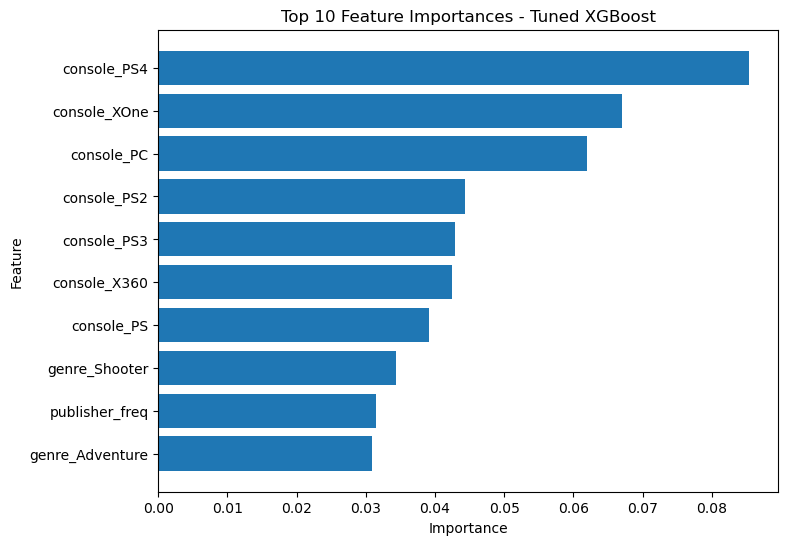

In [46]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Tuned XGBoost")

plt.gca().invert_yaxis()

plt.show()

### 8.2 SHAP Analysis

SHAP (SHapley Additive exPlanations) was used to provide a more detailed interpretation of the final XGBoost model.

Unlike feature importance, SHAP values show both the importance of a feature and its contribution to individual predictions.

In [47]:
explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(x_test)

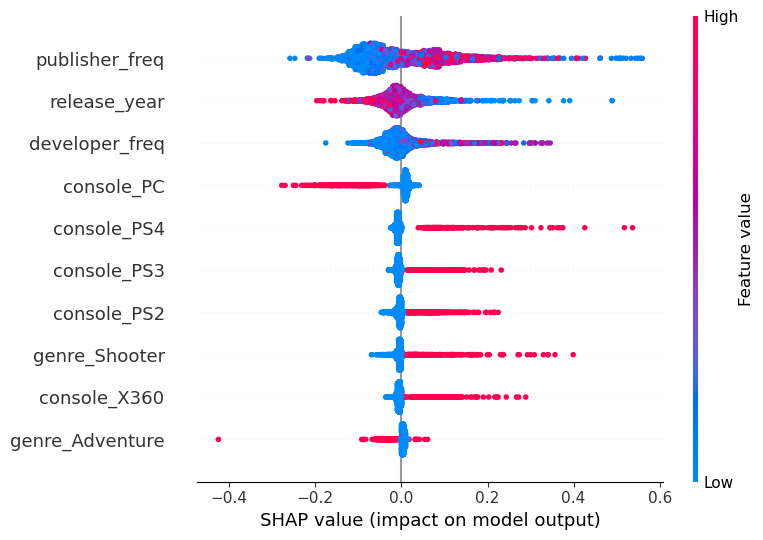

In [48]:
shap.summary_plot(
    shap_values,
    x_test,
    max_display=10
)

# 9. Final Model Evaluation

The final tuned XGBoost model was evaluated using actual versus predicted values and residual analysis.

### 9.1 Model Comparison Based on R²

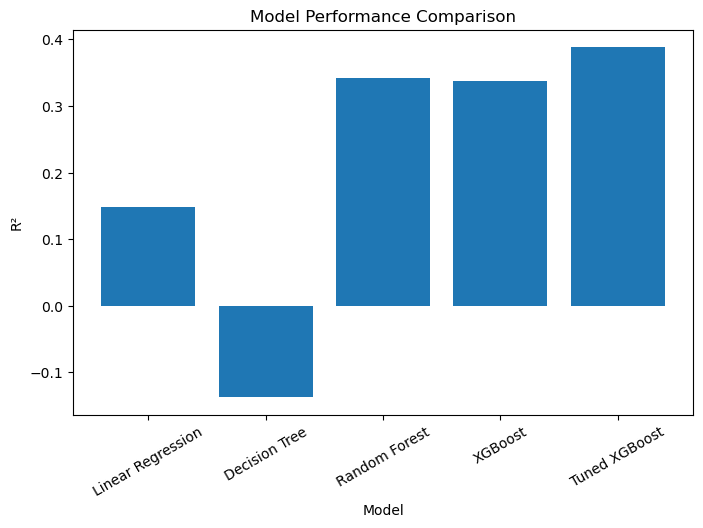

In [49]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["R2"]
)

plt.ylabel("R²")
plt.xlabel("Model")
plt.title("Model Performance Comparison")

plt.xticks(rotation=30)

plt.show()

### 9.2 Actual vs Predicted

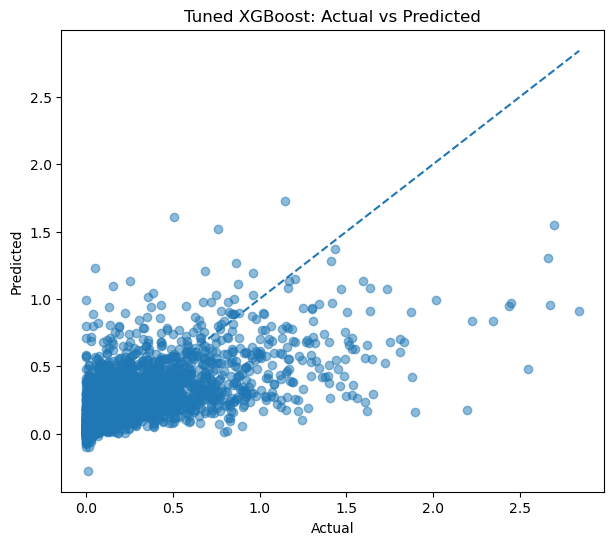

In [50]:
plt.figure(figsize=(7,6))

plt.scatter(
    y_test,
    tuned_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Tuned XGBoost: Actual vs Predicted")

plt.show()

### 9.3 Residual Analysis

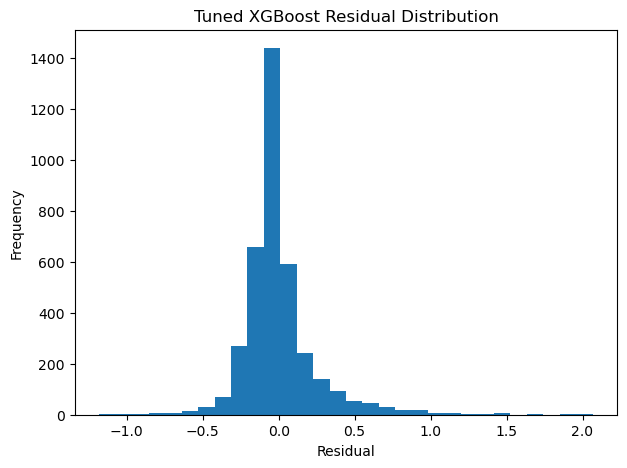

In [51]:
tuned_residuals = y_test - tuned_pred

plt.figure(figsize=(7,5))

plt.hist(
    tuned_residuals,
    bins=30
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Tuned XGBoost Residual Distribution")

plt.show()

# 10. Conclusion

This project aimed to predict video game sales using machine learning regression models.

After data cleaning and exploratory data analysis, missing values were handled, rare genre categories were removed, and the highly right-skewed sales variable was transformed using a logarithmic transformation.

Categorical variables were prepared using Frequency Encoding for publisher and developer, and One-Hot Encoding for console and genre.

Five regression models were evaluated: Linear Regression, Decision Tree, Random Forest, XGBoost, and Tuned XGBoost.

Among the evaluated models, Tuned XGBoost achieved the best overall performance, with an MAE of 0.1533, an RMSE of 0.2495, and an R² score of 0.3881.

Feature importance and SHAP analysis showed that platform-related features were among the most influential factors in the model, particularly PS4, Xbox One, and PC. Selected genre features and publisher frequency also contributed to the model's predictions.

Overall, the results show that ensemble tree-based models, particularly tuned XGBoost, were able to capture nonlinear patterns in video game sales more effectively than the simpler baseline models.

# 11. Limitations

- The dataset contains a substantial number of missing values in several variables.
- The target variable is highly right-skewed, requiring logarithmic transformation.
- The final model explains approximately 38.8% of the variation in the transformed sales target, meaning that important predictive factors are still missing.
- Frequency encoding of publisher and developer captures their frequency in the dataset but does not directly represent the identity of each company.
- The dataset does not include potentially important commercial variables such as marketing expenditure, game price, or advertising budget.
- Model performance may be affected by the available features and the quality of the original data.